In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, accuracy_score
from yellowbrick.classifier import ConfusionMatrix

In [2]:
# Carregamento da base de dados e definição dos previsores e a classe (x e y).

credito = pd.read_csv('C:/Users/mrwag/OneDrive/Big Data/DS/21.Textos/credit.csv')
credito.head()

,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,<0,6,'critical/other existing credit',radio/tv,1169,'no known savings',>=7,4,'male single',none,...,'real estate',67,none,own,2,skilled,1,yes,yes,good
1,0<=X<200,48,'existing paid',radio/tv,5951,<100,1<=X<4,2,'female div/dep/mar',none,...,'real estate',22,none,own,1,skilled,1,none,yes,bad
2,'no checking',12,'critical/other existing credit',education,2096,<100,4<=X<7,2,'male single',none,...,'real estate',49,none,own,1,'unskilled resident',2,none,yes,good
3,<0,42,'existing paid',furniture/equipment,7882,<100,4<=X<7,2,'male single',guarantor,...,'life insurance',45,none,'for free',1,skilled,2,none,yes,good
4,<0,24,'delayed previously','new car',4870,<100,1<=X<4,3,'male single',none,...,'no known property',53,none,'for free',2,skilled,2,none,yes,bad


In [3]:
# Formatando para matriz.

previsores = credito.iloc[:,0:20].values
classe = credito.iloc[:,20].values

In [4]:
# Transformação dos atributos categóricos em atributos numéricos, passando o índice de cada coluna.
# Precisamos criar um objeto para cada atributo categórico, para que passemos o processo encoding.

labelencoder1 = LabelEncoder()
previsores[:, 0] = labelencoder1.fit_transform(previsores[:,0])

labelencoder2 = LabelEncoder()
previsores[:, 2] = labelencoder2.fit_transform(previsores[:,2])

labelencoder3 = LabelEncoder()
previsores[:, 3] = labelencoder3.fit_transform(previsores[:,3])

labelencoder4 = LabelEncoder()
previsores[:, 5] = labelencoder4.fit_transform(previsores[:,5])

labelencoder5 = LabelEncoder()
previsores[:, 6] = labelencoder5.fit_transform(previsores[:,6])

labelencoder6 = LabelEncoder()
previsores[:, 8] = labelencoder6.fit_transform(previsores[:,8])

labelencoder7 = LabelEncoder()
previsores[:, 9] = labelencoder7.fit_transform(previsores[:,9])

labelencoder8 = LabelEncoder()
previsores[:, 11] = labelencoder8.fit_transform(previsores[:,11])

labelencoder9 = LabelEncoder()
previsores[:, 13] = labelencoder9.fit_transform(previsores[:,13])

labelencoder10 = LabelEncoder()
previsores[:, 14] = labelencoder10.fit_transform(previsores[:,14])

labelencoder11 = LabelEncoder()
previsores[:, 16] = labelencoder11.fit_transform(previsores[:,16])

labelencoder12 = LabelEncoder()
previsores[:, 18] = labelencoder12.fit_transform(previsores[:,18])

labelencoder13 = LabelEncoder()
previsores[:, 19] = labelencoder13.fit_transform(previsores[:,19])

In [5]:
# Dividindo a base de dados entre treinamento e teste.

X_treino, X_teste, Y_treino, Y_teste = train_test_split(previsores, classe, test_size= 0.3, random_state=0)

In [6]:
# Criação e treinamento do modelo (tabela de probabilidade).

naive_bayes = GaussianNB()
naive_bayes.fit(X_treino, Y_treino)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [7]:
# Previsões usando o registro de teste.

previsoes = naive_bayes.predict(X_teste)
previsoes

array(['bad', 'good', 'good', 'good', 'bad', 'good', 'good', 'good',
       'good', 'bad', 'bad', 'bad', 'good', 'bad', 'good', 'good', 'good',
       'good', 'bad', 'good', 'bad', 'good', 'bad', 'good', 'good', 'bad',
       'good', 'good', 'good', 'bad', 'good', 'good', 'good', 'good',
       'good', 'bad', 'good', 'good', 'good', 'good', 'good', 'bad',
       'good', 'good', 'good', 'bad', 'bad', 'bad', 'bad', 'bad', 'good',
       'bad', 'good', 'good', 'good', 'good', 'bad', 'good', 'good',
       'good', 'bad', 'good', 'good', 'good', 'good', 'good', 'good',
       'good', 'bad', 'good', 'good', 'good', 'good', 'good', 'bad',
       'good', 'good', 'good', 'good', 'good', 'good', 'good', 'good',
       'bad', 'good', 'good', 'bad', 'bad', 'good', 'bad', 'good', 'good',
       'good', 'good', 'good', 'good', 'good', 'good', 'good', 'good',
       'good', 'good', 'good', 'bad', 'good', 'good', 'bad', 'bad',
       'good', 'good', 'good', 'bad', 'good', 'good', 'bad', 'good',
      

In [8]:
# Geração da matriz de confusão.

confusao = confusion_matrix(Y_teste, previsoes)
confusao

array([[ 41,  45],
       [ 42, 172]])

In [9]:
# Calculando taxa de erro e de acerto.

acerto = accuracy_score(Y_teste, previsoes)
erros = 1 - acerto
#acerto
erros

0.29000000000000004

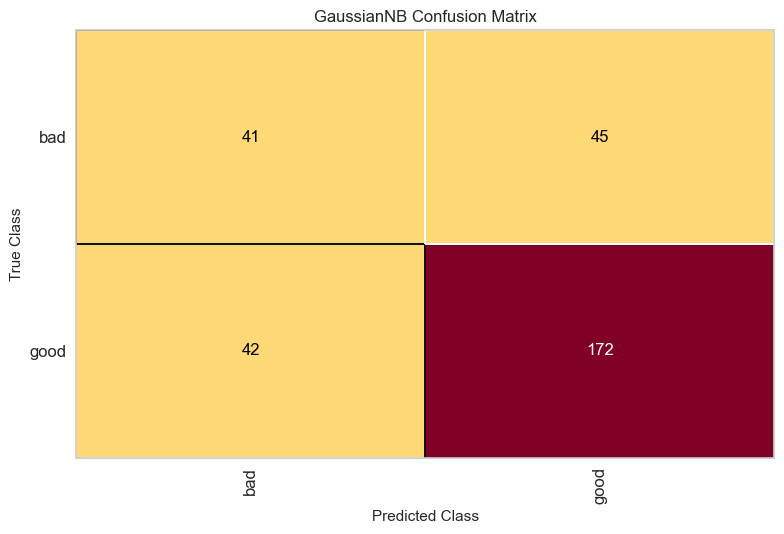

<Axes: title={'center': 'GaussianNB Confusion Matrix'}, xlabel='Predicted Class', ylabel='True Class'>

In [10]:
# Visualização da matriz de confusão.

v = ConfusionMatrix(GaussianNB(), force_model=True) # Usar o force model para que seja reconhecido o modelo.
v.fit(X_treino, Y_treino)
v.score(X_teste, Y_teste)
v.poof()

In [12]:
# Nova base de dados, transformando atributos categóricos em numéricos.

novo_credito = pd.read_csv('C:/Users/mrwag/OneDrive/Big Data/DS/21.Textos/novocredit.csv')
novo_credito.shape

(1, 20)

In [13]:
novo_credito.head(3)

,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,residence_since,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker
0,'no checking',12,'existing paid',radio/tv,804,<100,>=7,4,'male single',none,4,car,38,none,own,1,skilled,1,none,yes


In [ ]:
# Chamamos só o transform sem o fit, pois o fit já foi executado antes. 
# Transformação de categórico para numérico.

novo_credito = novo_credito.values # necessário para transformar dataframe em um array.
novo_credito = novo_credito[:,0:20]
novo_credito[:,0] = labelencoder1.fit_transform(novo_credito[:,0])
novo_credito[:,2] = labelencoder2.fit_transform(novo_credito[:,2])
novo_credito[:,3] = labelencoder3.fit_transform(novo_credito[:,3])
novo_credito[:,5] = labelencoder4.fit_transform(novo_credito[:,5])
novo_credito[:,6] = labelencoder5.fit_transform(novo_credito[:,6])
novo_credito[:,8] = labelencoder6.fit_transform(novo_credito[:,8])
novo_credito[:,9] = labelencoder7.fit_transform(novo_credito[:,9])
novo_credito[:,11] = labelencoder8.fit_transform(novo_credito[:,11])
novo_credito[:,13] = labelencoder9.fit_transform(novo_credito[:,13])
novo_credito[:,14] = labelencoder10.fit_transform(novo_credito[:,14])
novo_credito[:,16] = labelencoder11.fit_transform(novo_credito[:,16])
novo_credito[:,18] = labelencoder12.fit_transform(novo_credito[:,18])
novo_credito[:,19] = labelencoder13.fit_transform(novo_credito[:,19])


In [18]:
# Resultado da previsão.

naive_bayes.predict(novo_credito)

array(['good'], dtype='<U4')